# Exploratory Data Analysis

**Struttura del notebook**

1. Caricamento e struttura del dataset
2. Qualità dei dati: valori mancanti e duplicati
3. Struttura temporale del dataset
4. Pulizia del target e codifica delle binarie
5. Distribuzione del target
6. Distribuzione delle variabili numeriche
7. Analisi delle correlazioni
8. Analisi della multicollinearità (VIF e Condition Index)
9. Ridondanza fra `Rainfall` e `RainToday`
10. Relazione fra le variabili meteo e il target
11. Persistenza della pioggia
12. Direzione del vento
13. Stagionalità
14. Differenze fra località
15. Sintesi per la fase di modellazione

## 1. Caricamento e struttura del dataset

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [134]:
def load_dataset(filename="weatherAUS.csv", cartella="dataset"):
    for base in [Path.cwd(), *Path.cwd().parents]:
        file = base / cartella / filename
        if file.exists():
            return file
    raise FileNotFoundError(
        f"'{cartella}/{filename}' non trovato. Scarica il dataset da Kaggle "
        f"e mettilo nella cartella '{cartella}/' nella root del progetto."
    )

DATA_PATH = load_dataset()
df = pd.read_csv(DATA_PATH, parse_dates=["Date"], na_values="NA")

In [135]:
print("Righe e colonne:", df.shape)
print("Periodo:", df["Date"].min().date(), "->", df["Date"].max().date())
print("N. localita:", df["Location"].nunique())
df.info()

Righe e colonne: (145460, 23)
Periodo: 2007-11-01 -> 2017-06-25
N. localita: 49
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 no

### Controllo delle colonne a rischio di data leakage

`RISK_MM` è la quantità di pioggia in mm del **giorno successivo**, cioè la grandezza da cui
`RainTomorrow` è direttamente derivata (`RainTomorrow = RISK_MM > 1`). 

In [136]:
LEAK_COLS = ["RISK_MM"]
leaks = [c for c in LEAK_COLS if c in df.columns]
if leaks:
    print(f"ATTENZIONE: trovate e rimosse colonne di leakage diretto: {leaks}")
    df = df.drop(columns=leaks)
else:
    print("Nessuna colonna di leakage diretto (RISK_MM) presente. OK.")

Nessuna colonna di leakage diretto (RISK_MM) presente. OK.


In [137]:
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145460,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,2013-04-04 21:08:51.907053568,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
min,2007-11-01 00:00:00,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,2011-01-11 00:00:00,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,2013-06-02 00:00:00,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,2015-06-14 00:00:00,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,2017-06-25 00:00:00,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000
std,NaN,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665


## 2. Qualità dei dati: valori mancanti e duplicati

In [138]:
dup = df.duplicated().sum()
dup_key = df.duplicated(subset=["Date", "Location"]).sum()
print(f"Righe interamente duplicate: {dup}")
print(f"Coppie (Date, Location) duplicate: {dup_key}")
print("La coppia (Date, Location) identifica univocamente l'osservazione."
      if dup_key == 0 else "ATTENZIONE: la chiave (Date, Location) non e' univoca.")

Righe interamente duplicate: 0
Coppie (Date, Location) duplicate: 0
La coppia (Date, Location) identifica univocamente l'osservazione.


In [139]:
missing = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
missing = missing[missing > 0]
for col, pct in missing.items():
    print(f"La colonna '{col}' ha {pct}% di valori mancanti.")

La colonna 'Sunshine' ha 48.01% di valori mancanti.
La colonna 'Evaporation' ha 43.17% di valori mancanti.
La colonna 'Cloud3pm' ha 40.81% di valori mancanti.
La colonna 'Cloud9am' ha 38.42% di valori mancanti.
La colonna 'Pressure9am' ha 10.36% di valori mancanti.
La colonna 'Pressure3pm' ha 10.33% di valori mancanti.
La colonna 'WindDir9am' ha 7.26% di valori mancanti.
La colonna 'WindGustDir' ha 7.1% di valori mancanti.
La colonna 'WindGustSpeed' ha 7.06% di valori mancanti.
La colonna 'Humidity3pm' ha 3.1% di valori mancanti.
La colonna 'WindDir3pm' ha 2.91% di valori mancanti.
La colonna 'Temp3pm' ha 2.48% di valori mancanti.
La colonna 'RainTomorrow' ha 2.25% di valori mancanti.
La colonna 'Rainfall' ha 2.24% di valori mancanti.
La colonna 'RainToday' ha 2.24% di valori mancanti.
La colonna 'WindSpeed3pm' ha 2.11% di valori mancanti.
La colonna 'Humidity9am' ha 1.82% di valori mancanti.
La colonna 'WindSpeed9am' ha 1.21% di valori mancanti.
La colonna 'Temp9am' ha 1.21% di valori

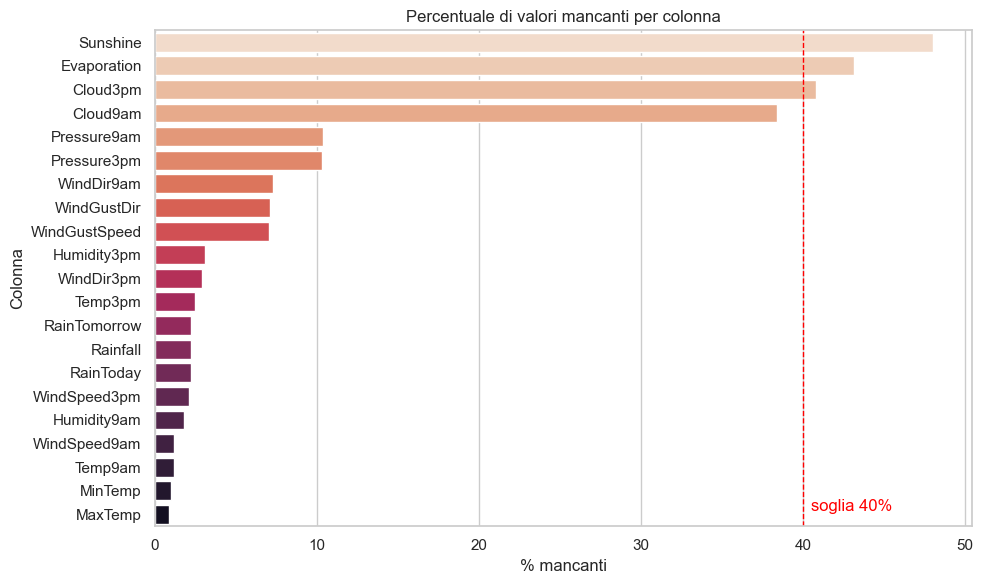

In [140]:
plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values, y=missing.index, hue=missing.index,
            palette="rocket_r", legend=False)
plt.title("Percentuale di valori mancanti per colonna")
plt.xlabel("% mancanti")
plt.ylabel("Colonna")
plt.axvline(40, color="red", ls="--", lw=1)
plt.text(40.5, len(missing)-1, "soglia 40%", color="red", va="bottom")
plt.tight_layout()
plt.show()

### I mancanti sono strutturali (per intere località)

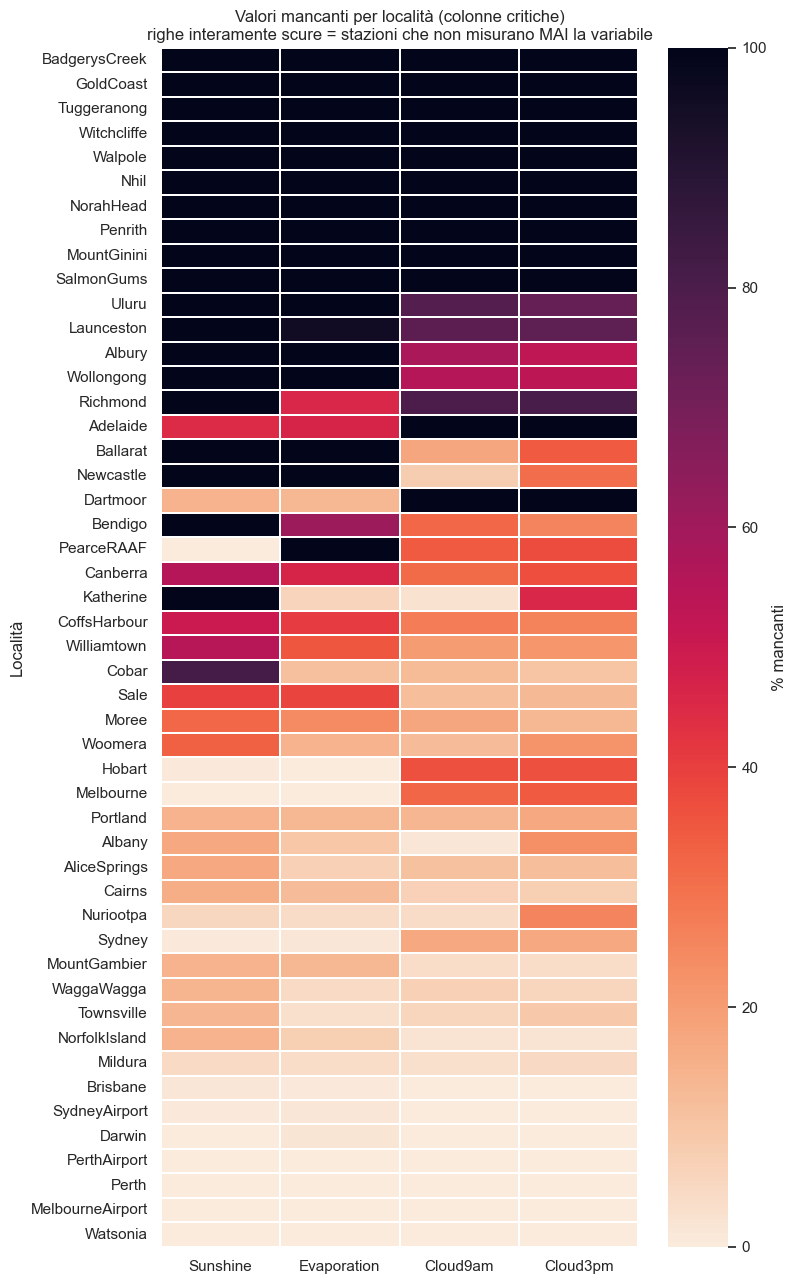

Località che non misurano MAI la variabile (100% mancante):
  Sunshine    : 19/49 località
  Evaporation : 16/49 località
  Cloud9am    : 12/49 località
  Cloud3pm    : 12/49 località


In [141]:
critiche = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]

# % di mancanti per ogni località su ciascuna colonna critica
miss_loc = (df[critiche].isna().groupby(df["Location"]).mean() * 100)
# ordina le località dalla più incompleta alla più completa
miss_loc = miss_loc.loc[miss_loc.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(8, 13))
sns.heatmap(miss_loc, cmap="rocket_r", vmin=0, vmax=100,
            cbar_kws={"label": "% mancanti"}, linewidths=.3, linecolor="white")
plt.title("Valori mancanti per località (colonne critiche)\n"
          "righe interamente scure = stazioni che non misurano MAI la variabile")
plt.xlabel(""); plt.ylabel("Località")
plt.tight_layout()
plt.show()

# Riepilogo numerico: quante località non misurano la variabile
print("Località che non misurano MAI la variabile (100% mancante):")
n_loc = df["Location"].nunique()
for c in critiche:
    n = (miss_loc[c] > 99).sum()
    print(f"  {c:12s}: {n}/{n_loc} località")

## 3. Struttura temporale del dataset

In [142]:
print("Il file e' ordinato per data?", df["Date"].is_monotonic_increasing)
print("\nPrime 3 righe del file:")
print(df[["Date", "Location"]].head(3).to_string(index=False))
print("\nUltime 3 righe del file:")
print(df[["Date", "Location"]].tail(3).to_string(index=False))

righe_per_data = df.groupby("Date").size()
print(f"\nOsservazioni per giornata: mediana {righe_per_data.median():.0f}, "
      f"min {righe_per_data.min()}, max {righe_per_data.max()}")

Il file e' ordinato per data? False

Prime 3 righe del file:
      Date Location
2008-12-01   Albury
2008-12-02   Albury
2008-12-03   Albury

Ultime 3 righe del file:
      Date Location
2017-06-23    Uluru
2017-06-24    Uluru
2017-06-25    Uluru

Osservazioni per giornata: mediana 46, min 1, max 49


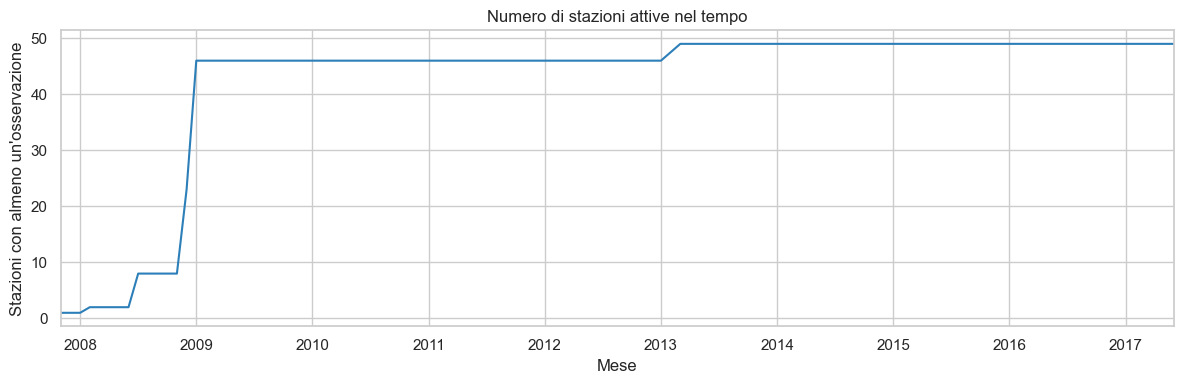

Stazioni con storico piu' corto:
                  min        max  size
Location                              
Nhil       2013-03-01 2017-06-25  1578
Katherine  2013-03-01 2017-06-25  1578
Uluru      2013-03-01 2017-06-25  1578
SalmonGums 2009-01-01 2017-06-25  3001
NorahHead  2009-01-01 2017-06-25  3004


In [143]:
# Copertura temporale: quante stazioni sono attive in ogni momento
attive = df.groupby(df["Date"].dt.to_period("M"))["Location"].nunique()
plt.figure(figsize=(12, 4))
attive.plot(color="#2C7FB8")
plt.title("Numero di stazioni attive nel tempo")
plt.xlabel("Mese"); plt.ylabel("Stazioni con almeno un'osservazione")
plt.tight_layout(); plt.show()

primo_ultimo = df.groupby("Location")["Date"].agg(["min", "max", "size"])
print("Stazioni con storico piu' corto:")
print(primo_ultimo.sort_values("size").head(5).to_string())

### La pioggia è autocorrelata nel tempo

È la ragione per cui uno split casuale produrrebbe metriche ottimistiche: giorni vicini della
stessa località sono quasi duplicati e gli eventi di pioggia si presentano a grappoli di più
giorni. Mettendo il giorno *t* nel test e i giorni *t−1* e *t+1* nel training, i due insiemi
non sarebbero indipendenti.

C'è anche una relazione strutturale fra righe consecutive:
`RainTomorrow(loc, t) == RainToday(loc, t+1)`. Il target di oggi è cioè scritto fra le feature
della riga di domani. Non è sfruttabile da un modello che non usa la data come chiave, ma
diventerebbe leakage diretto se si aggiungessero feature di lag o medie mobili.

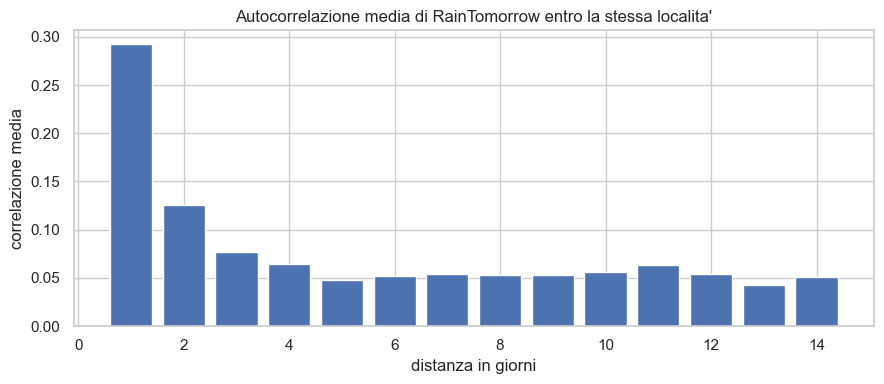

Autocorrelazione a 1 giorno : 0.292
Autocorrelazione a 7 giorni : 0.054

--> Autocorrelazione marcata: giorni adiacenti NON sono indipendenti.
    Uno split casuale mescolerebbe informazione fra train e test e
    produrrebbe metriche ottimistiche. Serve uno split cronologico.


In [144]:
# Autocorrelazione del target entro ciascuna localita', a distanza crescente di giorni.
# Le serie vanno ordinate per (Location, Date) altrimenti il lag non ha significato.
d_ord = df.sort_values(["Location", "Date"])
piove = d_ord["RainTomorrow"].map({"No": 0, "Yes": 1})

lags = list(range(1, 15))
autocorr = [piove.groupby(d_ord["Location"]).apply(lambda s: s.autocorr(lag=k)).mean()
            for k in lags]

plt.figure(figsize=(9, 4))
plt.bar(lags, autocorr, color="#4C72B0")
plt.axhline(0, color="black", lw=.8)
plt.title("Autocorrelazione media di RainTomorrow entro la stessa localita'")
plt.xlabel("distanza in giorni"); plt.ylabel("correlazione media")
plt.tight_layout(); plt.show()

print(f"Autocorrelazione a 1 giorno : {autocorr[0]:.3f}")
print(f"Autocorrelazione a 7 giorni : {autocorr[6]:.3f}")

# La conclusione viene dal dato misurato, non e' scritta a codice fisso.
if autocorr[0] > 0.10:
    print("\n--> Autocorrelazione marcata: giorni adiacenti NON sono indipendenti.")
    print("    Uno split casuale mescolerebbe informazione fra train e test e")
    print("    produrrebbe metriche ottimistiche. Serve uno split cronologico.")
else:
    print("\n--> Autocorrelazione debole su questi dati. Lo split cronologico resta")
    print("    comunque la scelta corretta, perche' la previsione meteo e' per")
    print("    definizione un problema in cui non si puo' usare il futuro.")

## 4. Pulizia del target e codifica delle binarie

In [145]:
prima = len(df)
df = df.dropna(subset=["RainTomorrow"]).copy()
print(f"Righe prima: {prima}  ->  dopo dropna sul target: {len(df)}  (rimosse {prima - len(df)})")

Righe prima: 145460  ->  dopo dropna sul target: 142193  (rimosse 3267)


- `RainToday` e `RainTomorrow`: `Yes/No` → `1/0`.
- Le direzioni del vento (`WindGustDir`, `WindDir9am`, `WindDir3pm`) sono 16 classi cardinali:
  si lasciano come stringhe per i grafici di questo notebook; il **one-hot encoding** verrà fatto
  nella fase di modellazione.

In [146]:
# Mappatura delle variabili categoriche binarie in 0/1.
# is_numeric_dtype rende la cella rieseguibile: se e' gia' stata applicata, non fa nulla.
# (Un secondo .map() trasformerebbe gli 0/1 in NaN, distruggendo il target.)
binary_map = {"No": 0, "Yes": 1}
for c in ["RainToday", "RainTomorrow"]:
    if not pd.api.types.is_numeric_dtype(df[c]):
        df[c] = df[c].map(binary_map)

df[["RainToday", "RainTomorrow"]].head()

,RainToday,RainTomorrow
0,0.0,0
1,0.0,0
2,0.0,0
3,0.0,0
4,0.0,0


## 5. Distribuzione del target — sbilanciamento delle classi

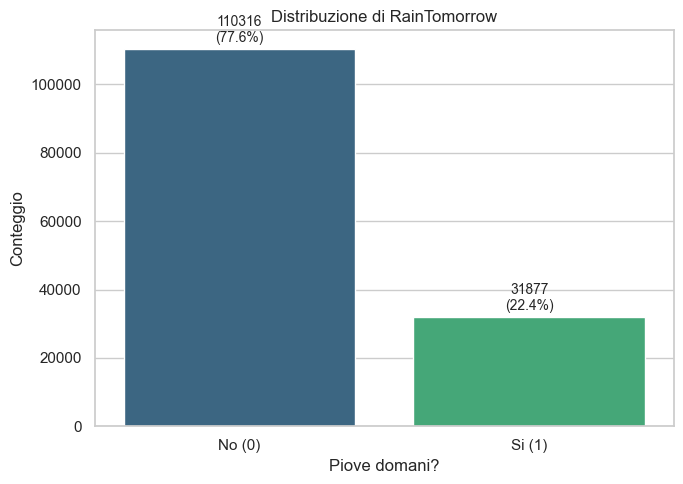

In [147]:
plt.figure(figsize=(7, 5))
ax = sns.countplot(x="RainTomorrow", data=df, hue="RainTomorrow",
                   palette="viridis", legend=False)
ax.set_xticks([0, 1]); ax.set_xticklabels(["No (0)", "Si (1)"])
plt.title("Distribuzione di RainTomorrow")
plt.xlabel("Piove domani?"); plt.ylabel("Conteggio")

tot = len(df)
for p in ax.patches:
    h = int(p.get_height())
    ax.annotate(f"{h}\n({h/tot*100:.1f}%)",
                (p.get_x() + p.get_width()/2., h),
                ha="center", va="bottom", fontsize=10, xytext=(0, 3),
                textcoords="offset points")
plt.tight_layout()
plt.show()

In [148]:
# Il target e' stabile nel tempo? Serve a capire se uno split cronologico
# produrrebbe train e test con proporzioni di classe confrontabili.
per_anno = df.groupby(df["Date"].dt.year)["RainTomorrow"].agg(["mean", "size"])
per_anno["mean"] = (per_anno["mean"] * 100).round(1)
print("% di giorni con pioggia il giorno dopo, per anno:")
print(per_anno.rename(columns={"mean": "% pioggia", "size": "osservazioni"}).to_string())

% di giorni con pioggia il giorno dopo, per anno:
      % pioggia  osservazioni
Date                         
2007       31.1            61
2008       22.8          2246
2009       21.7         16595
2010       24.3         16419
2011       24.7         15126
2012       22.5         15044
2013       21.5         16097
2014       20.4         17400
2015       21.2         17231
2016       23.9         17508
2017       20.8          8466


## 6. Distribuzione delle variabili numeriche

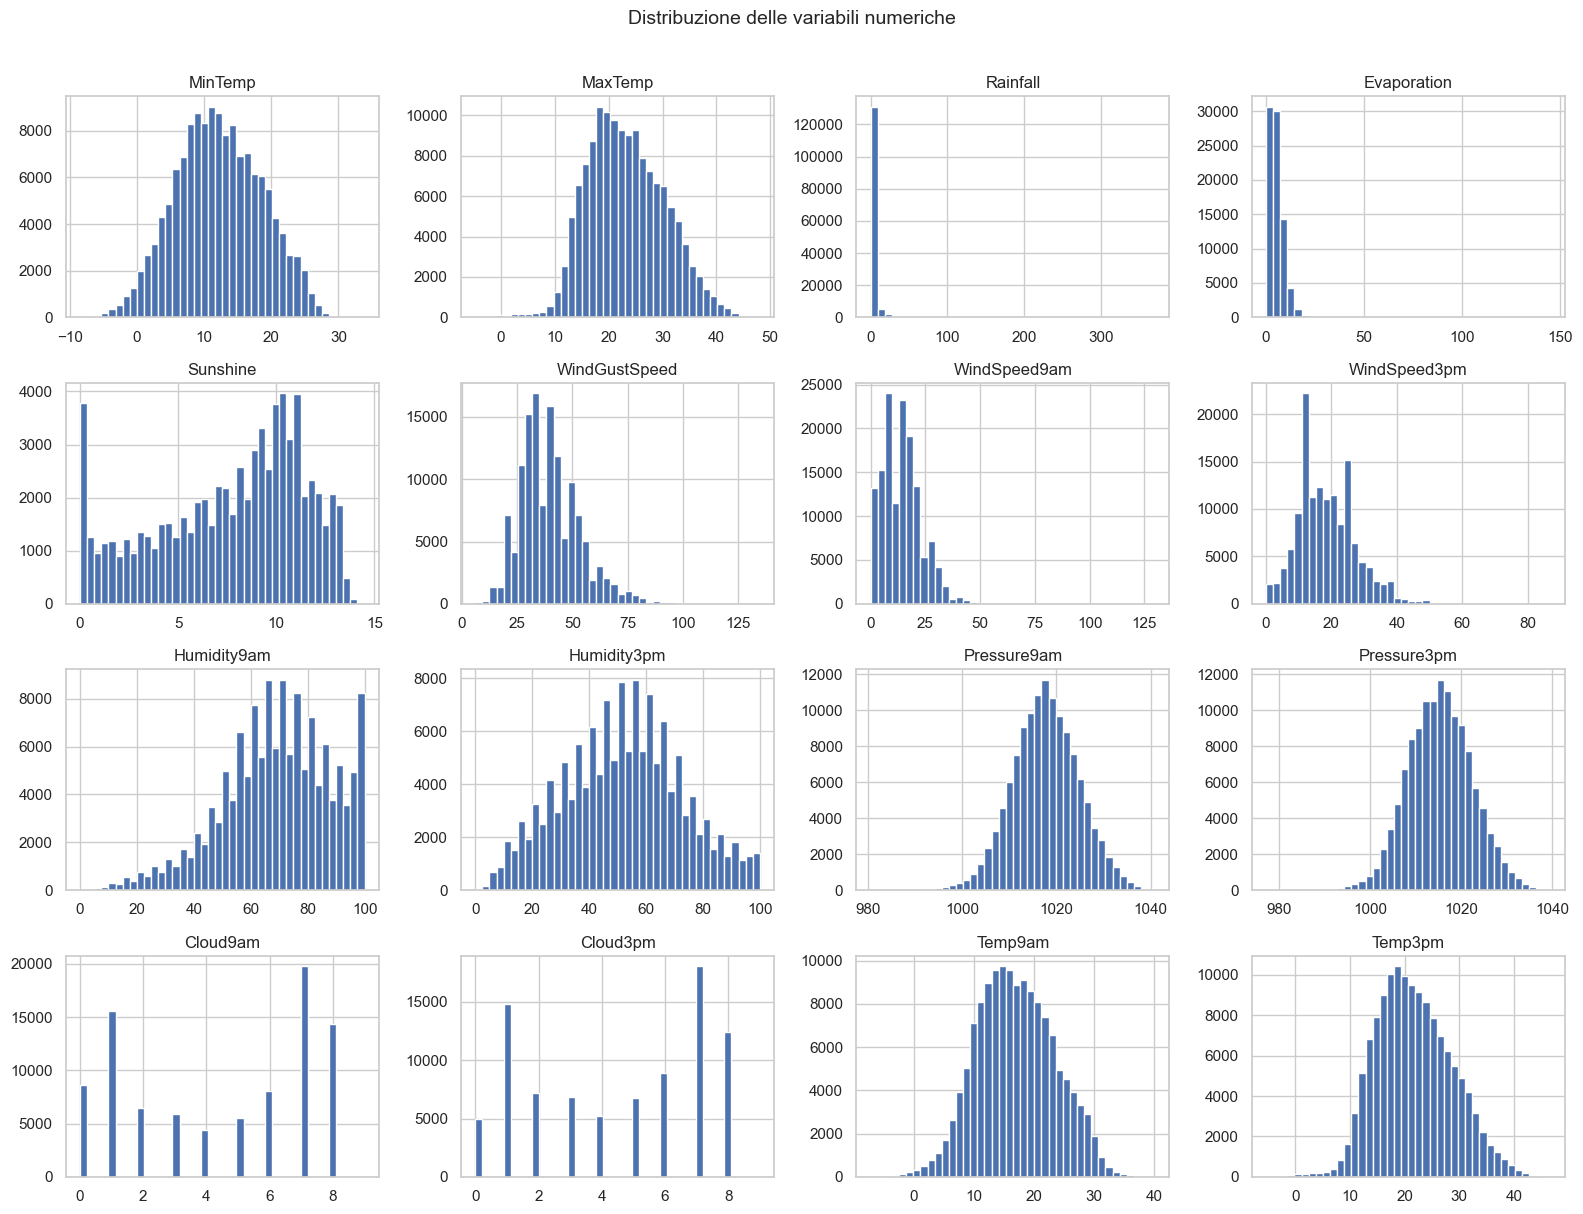

In [149]:
num_cols = df.select_dtypes(include="number").columns.drop(["RainToday", "RainTomorrow"])
df[num_cols].hist(bins=40, figsize=(16, 12), color="#4C72B0", edgecolor="white")
plt.suptitle("Distribuzione delle variabili numeriche", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [150]:
# Asimmetria: le variabili molto sbilanciate penalizzano i modelli lineari
skew = df[num_cols].skew().sort_values(ascending=False)
print("Indice di asimmetria (skewness):")
print(skew.round(2).to_string())
print("\n|skew| > 2 indica una coda molto pesante: candidata a trasformazione logaritmica.")

Indice di asimmetria (skewness):
Rainfall         9.89
Evaporation      3.75
WindGustSpeed    0.87
WindSpeed9am     0.78
WindSpeed3pm     0.63
Temp3pm          0.24
MaxTemp          0.22
Temp9am          0.09
Humidity3pm      0.03
MinTemp          0.02
Pressure3pm     -0.05
Pressure9am     -0.10
Cloud3pm        -0.22
Cloud9am        -0.22
Humidity9am     -0.48
Sunshine        -0.50

|skew| > 2 indica una coda molto pesante: candidata a trasformazione logaritmica.


## 7. Analisi delle correlazioni

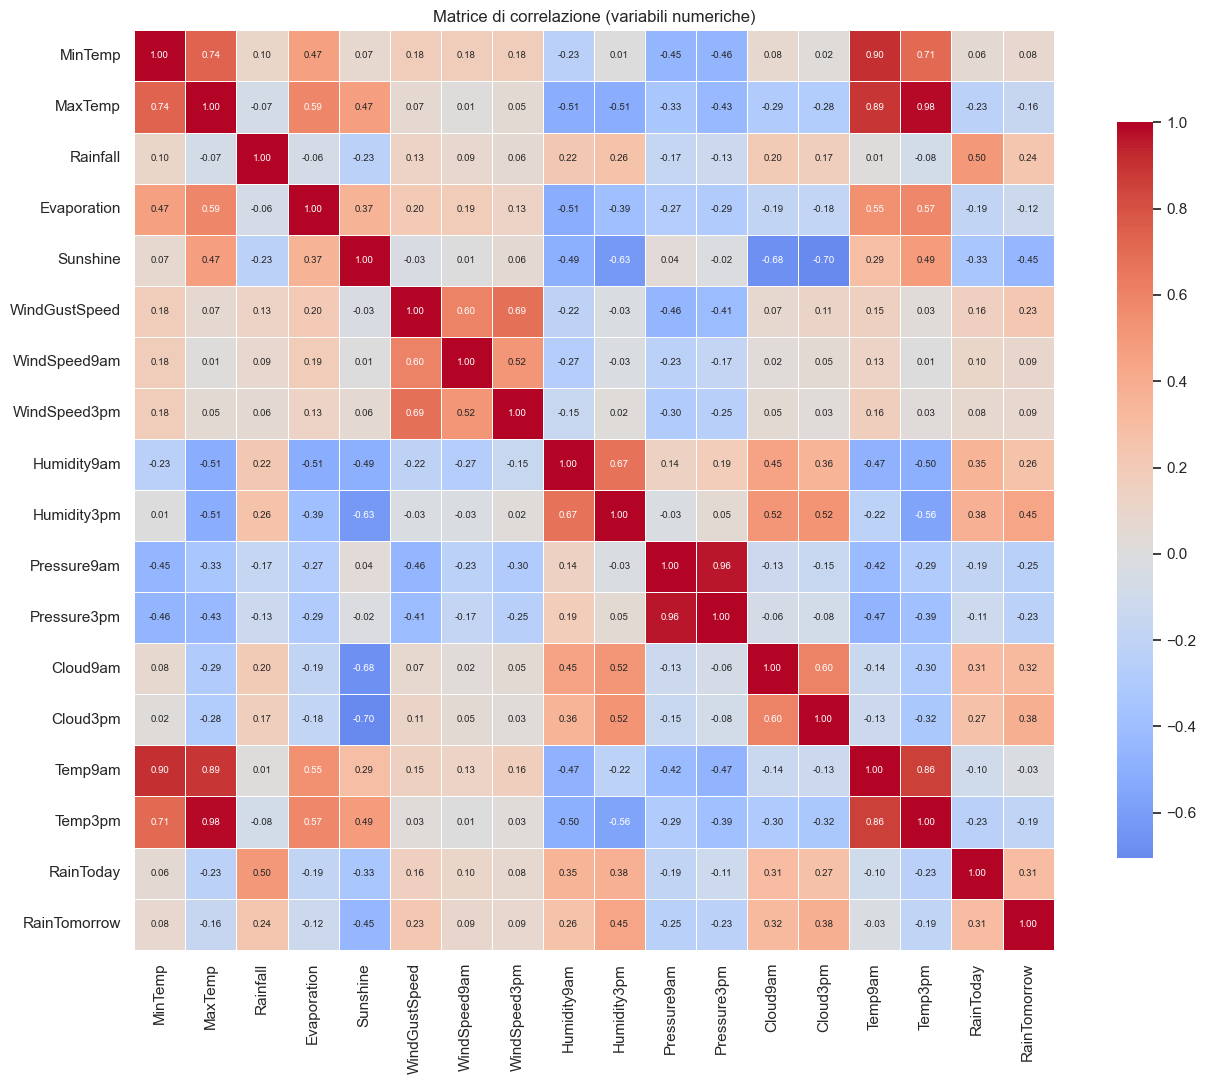

In [151]:
plt.figure(figsize=(14, 11))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, annot_kws={"size": 7},
            cbar_kws={"shrink": .8})
plt.title("Matrice di correlazione (variabili numeriche)")
plt.tight_layout()
plt.show()

In [152]:
# Variabili piu correlate (in valore assoluto) con il target
target_corr = corr["RainTomorrow"].drop("RainTomorrow").abs().sort_values(ascending=False)
print("Correlazione |assoluta| con RainTomorrow:")
print(target_corr.round(3).to_string())

Correlazione |assoluta| con RainTomorrow:
Sunshine         0.451
Humidity3pm      0.446
Cloud3pm         0.382
Cloud9am         0.317
RainToday        0.313
Humidity9am      0.257
Pressure9am      0.246
Rainfall         0.239
WindGustSpeed    0.234
Pressure3pm      0.226
Temp3pm          0.192
MaxTemp          0.159
Evaporation      0.119
WindSpeed9am     0.091
WindSpeed3pm     0.088
MinTemp          0.084
Temp9am          0.026


## 8. Analisi della multicollinearità

La matrice di correlazione mostra relazioni a due a due, ma non basta: una variabile può essere
poco correlata con ciascuna delle altre presa singolarmente e comunque essere quasi
ricostruibile da una loro combinazione lineare. Questa è la **multicollinearità**, e su questo
dataset è attesa perché le stesse grandezze fisiche sono misurate due volte al giorno (9:00 e
15:00) o come minimo e massimo.

Non danneggia l'accuratezza dei modelli ad albero, che semplicemente ignorano la variabile
ridondante, ma rende instabili e non interpretabili i coefficienti dei modelli lineari
(regressione logistica, SVM lineare), perché la varianza delle stime si gonfia.

Si usano due strumenti complementari alla correlazione di Pearson:

* **Variance Inflation Factor (VIF)** — quanto la varianza del coefficiente della variabile *j*
  è gonfiata dalla sua correlazione con **tutte** le altre insieme;
* **Condition Index** — diagnostica globale sugli autovalori, rileva dipendenze lineari quasi
  perfette anche quando nessuna singola coppia è particolarmente correlata.

### Definizione e implementazione

$$VIF_j = \frac{1}{1 - R_j^2}$$

dove $R_j^2$ è il coefficiente di determinazione della regressione della variabile *j* su tutte
le altre. Convenzione di lettura: $VIF = 1$ nessuna collinearità, $1 < VIF < 5$ moderata,
$VIF \geq 10$ elevata e problematica.

**L'errore da evitare.** L'implementazione più diffusa,
`statsmodels.stats.outliers_influence.variance_inflation_factor`, richiede che la matrice
contenga una colonna costante. Se la si dimentica, la regressione interna è forzata a passare
per l'origine e $R_j^2$ risulta enorme per ogni variabile con media lontana da zero. Su questo
dataset `Pressure9am` ha media 1017: senza intercetta il suo VIF verrebbe stimato nell'ordine
delle migliaia, un numero privo di significato.

Qui si usa un'identità algebrica equivalente e immune al problema: **il VIF è la diagonale
dell'inversa della matrice di correlazione** dei predittori. Lavorando sulla correlazione le
variabili sono già centrate e standardizzate, quindi l'intercetta è inclusa per costruzione, e
il risultato coincide esattamente con quello della regressione con costante.

**Il target va escluso.** Il VIF misura la collinearità *fra i predittori*: la correlazione fra
una feature e `RainTomorrow` è il segnale che il modello deve sfruttare, non un difetto da
eliminare. Includere il target risponderebbe a una domanda diversa e porterebbe a scartare
proprio le variabili più utili.

In [153]:
def vif_table(frame, cols):
    # VIF_j = [R^-1]_jj, con R matrice di correlazione dei predittori.
    # Equivale a 1/(1-R2_j) di una OLS CON intercetta, senza il rischio di dimenticare
    # la colonna costante. pinv al posto di inv per robustezza numerica.
    assert len(set(cols)) == len(cols), \
        f"colonne duplicate: {[c for c in set(cols) if list(cols).count(c) > 1]}"
    sub = frame[list(cols)].dropna()
    R = np.corrcoef(sub.values, rowvar=False)
    return (pd.Series(np.diag(np.linalg.pinv(R)), index=list(cols), name="VIF")
              .sort_values(ascending=False))

def condition_index(frame, cols):
    # CI = sqrt(autovalore max / autovalore min) della matrice di correlazione.
    # > 10 collinearita' moderata, > 30 severa.
    assert len(set(cols)) == len(cols), "colonne duplicate"
    sub = frame[list(cols)].dropna()
    eig = np.clip(np.linalg.eigvalsh(np.corrcoef(sub.values, rowvar=False)), 1e-12, None)
    return float(np.sqrt(eig.max() / eig.min()))

### Scelta dei predittori da includere

Due esclusioni oltre al target:

* **`Month`** è ciclica e nella fase di modellazione entra come categorica (one-hot), quindi
  trattarla qui come numerica continua misurerebbe una collinearità che nel modello non esiste;
* le **colonne a mancanza strutturale** vengono valutate a parte. Il VIF non tollera i valori
  mancanti e richiede il `dropna`: includendo `Sunshine`, che manca nel 48% dei casi, si scende
  a poche migliaia di righe complete, per giunta non rappresentative perché provengono quasi
  solo dalle stazioni meglio strumentate. Il calcolo viene quindi ripetuto sui due insiemi e si
  confrontano i risultati.

In [154]:
TARGET = "RainTomorrow"
SPARSE = ["Sunshine", "Evaporation", "Cloud9am", "Cloud3pm"]
ESCLUSE = [TARGET, "Month"]

pred_all  = [c for c in df.select_dtypes(include="number").columns if c not in ESCLUSE]
pred_core = [c for c in pred_all if c not in SPARSE]

print(f"Predittori considerati ({len(pred_all)}):\n  {pred_all}\n")
for etichetta, cols in [("tutte le numeriche", pred_all),
                        ("senza colonne sparse", pred_core)]:
    n = df[cols].dropna().shape[0]
    print(f"{etichetta:22s} -> {len(cols):2d} variabili | {n:>7,} righe complete "
          f"({n/len(df):5.1%}) | Condition Index = {condition_index(df, cols):7.2f}")

Predittori considerati (17):
  ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']

tutte le numeriche     -> 17 variabili |  58,090 righe complete (40.9%) | Condition Index =   23.70
senza colonne sparse   -> 13 variabili | 119,590 righe complete (84.1%) | Condition Index =   21.22


### Correlazione fra i soli predittori e coppie problematiche

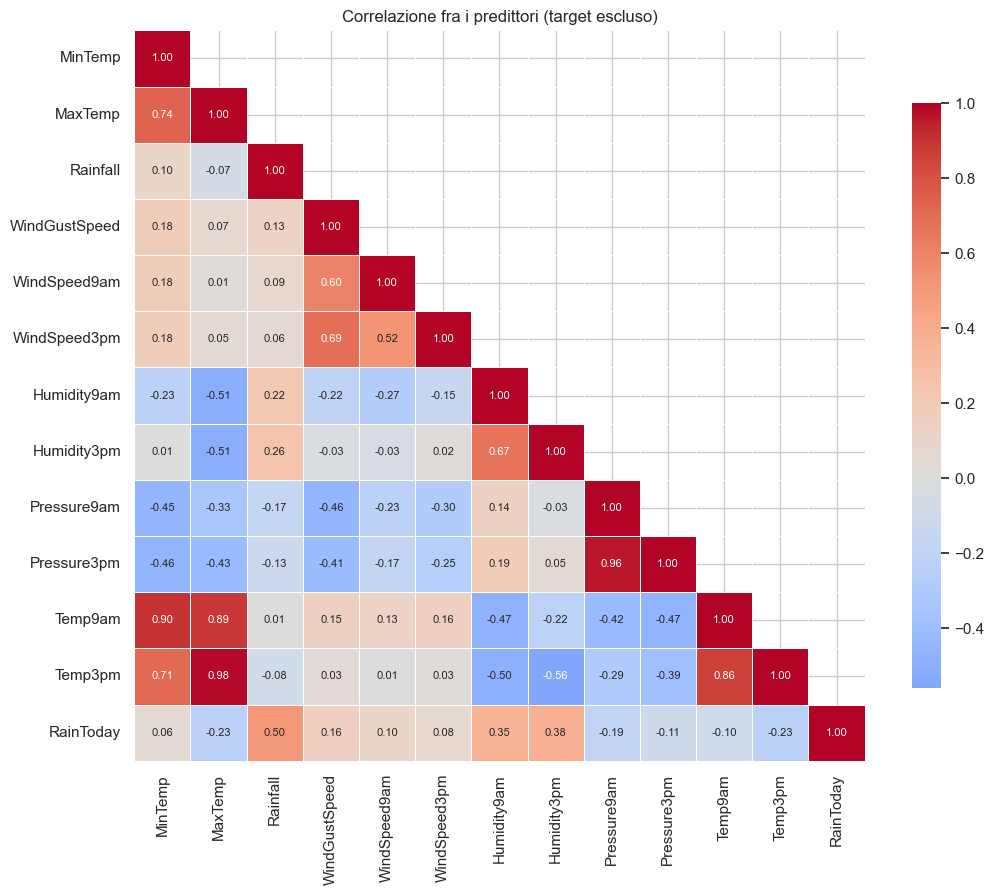

Coppie con |correlazione| > 0.7:
      var_1       var_2  correlazione
    MaxTemp     Temp3pm         0.985
Pressure9am Pressure3pm         0.961
    MinTemp     Temp9am         0.902
    MaxTemp     Temp9am         0.887
    Temp9am     Temp3pm         0.861
    MinTemp     MaxTemp         0.736
    MinTemp     Temp3pm         0.709


In [155]:
corr_pred = df[pred_core].corr()
mask = np.triu(np.ones_like(corr_pred, dtype=bool), k=1)

plt.figure(figsize=(11, 9))
sns.heatmap(corr_pred, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, annot_kws={"size": 8}, cbar_kws={"shrink": .8})
plt.title("Correlazione fra i predittori (target escluso)")
plt.tight_layout(); plt.show()

coppie = (corr_pred.where(mask).stack().rename("correlazione").reset_index()
          .rename(columns={"level_0": "var_1", "level_1": "var_2"}))
coppie["abs"] = coppie["correlazione"].abs()
print("Coppie con |correlazione| > 0.7:")
print(coppie[coppie["abs"] > 0.7].sort_values("abs", ascending=False)
      [["var_1", "var_2", "correlazione"]].round(3).to_string(index=False))

### VIF e Condition Index

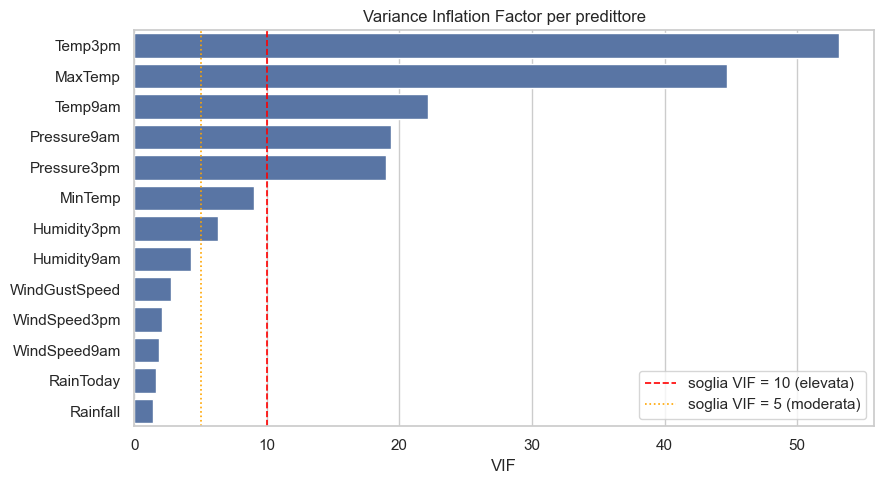

Temp3pm          53.13
MaxTemp          44.69
Temp9am          22.14
Pressure9am      19.33
Pressure3pm      18.99
MinTemp           9.01
Humidity3pm       6.28
Humidity9am       4.27
WindGustSpeed     2.79
WindSpeed3pm      2.08
WindSpeed9am      1.88
RainToday         1.64
Rainfall          1.37

Condition Index: 21.22
Riferimento: CI > 10 collinearita' moderata, CI > 30 severa.
Variabili sopra la soglia VIF=10: ['Temp3pm', 'MaxTemp', 'Temp9am', 'Pressure9am', 'Pressure3pm']


In [156]:
vif_core = vif_table(df, pred_core)

plt.figure(figsize=(9, 5))
sns.barplot(x=vif_core.values, y=vif_core.index, color="#4C72B0")
plt.axvline(10, color="red",    ls="--", lw=1.2, label="soglia VIF = 10 (elevata)")
plt.axvline(5,  color="orange", ls=":",  lw=1.2, label="soglia VIF = 5 (moderata)")
plt.title("Variance Inflation Factor per predittore")
plt.xlabel("VIF"); plt.ylabel(""); plt.legend()
plt.tight_layout(); plt.show()

print(vif_core.round(2).to_string())
print(f"\nCondition Index: {condition_index(df, pred_core):.2f}")
print("Riferimento: CI > 10 collinearita' moderata, CI > 30 severa.")
print(f"Variabili sopra la soglia VIF=10: {list(vif_core[vif_core > 10].index)}")

### Rimozione iterativa (greedy)

Procedura diagnostica standard: si elimina la variabile con VIF più alto, si ricalcola, si
ripete finché tutti i valori scendono sotto la soglia. Serve a quantificare **quante e quali**
variabili sono ridondanti.

L'algoritmo guarda solo la
collinearità e ignora completamente il potere predittivo, quindi tende a eliminare proprio le
variabili più correlate col target.

In [157]:
def vif_greedy(frame, cols, soglia=5.0, verbose=True):
    rimasti, scartati = list(cols), []
    while len(rimasti) > 1:
        v = vif_table(frame, rimasti)
        if v.iloc[0] <= soglia:
            break
        peggiore = v.index[0]
        if verbose:
            print(f"  rimuovo {peggiore:15s} (VIF = {v.iloc[0]:8.2f})")
        scartati.append(peggiore)
        rimasti.remove(peggiore)
    return rimasti, scartati

print(f"Rimozione iterativa fino a VIF < 5:")
tenuti, buttati = vif_greedy(df, pred_core, soglia=5.0)
print(f"\nMantenute ({len(tenuti)}): {tenuti}")
print(f"Scartate  ({len(buttati)}): {buttati}")
print(f"Condition Index dopo la rimozione: {condition_index(df, tenuti):.2f}")

print("\nCorrelazione col target delle variabili SCARTATE dal greedy:")
print(target_corr[buttati].round(3).to_string())
print("--> Diagnosi: il greedy elimina variabili fra le piu' predittive")

Rimozione iterativa fino a VIF < 5:
  rimuovo Temp3pm         (VIF =    53.13)
  rimuovo Temp9am         (VIF =    21.10)
  rimuovo Pressure9am     (VIF =    17.79)
  rimuovo MaxTemp         (VIF =     5.90)

Mantenute (9): ['MinTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure3pm', 'RainToday']
Scartate  (4): ['Temp3pm', 'Temp9am', 'Pressure9am', 'MaxTemp']
Condition Index dopo la rimozione: 3.33

Correlazione col target delle variabili SCARTATE dal greedy:
Temp3pm        0.192
Temp9am        0.026
Pressure9am    0.246
MaxTemp        0.159
--> Diagnosi: il greedy elimina variabili fra le piu' predittive


### Strategie di mitigazione

Possiamo analizzare tre strategie:

* **eliminare i predittori ridondanti** — semplice, ma perde informazione e, come mostrato
  sopra, rischia di colpire le variabili più utili;
* **combinarli con la PCA** — riduce la dimensionalità ma le componenti perdono
  l'interpretazione fisica;
* **costruire feature derivate fisicamente sensate** — sostituire una coppia collineare con
  grandezze che hanno un significato proprio.

La terza via è quella più difendibile qui. Le coppie collineari nascono tutte dal fatto che la
stessa grandezza è misurata due volte nella giornata, quindi si può sostituire ogni coppia con
**un livello e una variazione**:

| feature derivata | definizione | significato |
|---|---|---|
| `TempRange` | `MaxTemp - MinTemp` | escursione termica: ampia col sereno, ridotta con copertura nuvolosa |
| `PressureTrend` | `Pressure3pm - Pressure9am` | **tendenza barometrica**: pressione in calo = fronte in avvicinamento |
| `HumidityTrend` | `Humidity3pm - Humidity9am` | evoluzione dell'umidità nella giornata |
| `WindTrend` | `WindSpeed3pm - WindSpeed9am` | rinforzo o attenuazione del vento |

Si mantengono i valori delle 15:00, più vicini al momento della previsione e più correlati col
target, e si scartano quelli delle 9:00, ricostruibili dalla differenza. La trasformazione è
**invertibile**: l'informazione è la stessa, cambia solo la base in cui è espressa.

La cella seguente misura solo l'effetto, in quanto **non viene
applicato automaticamente** nel notebook di classificazione: il modello finale è basato su
alberi, insensibili alla collinearità, quindi la scelta va motivata dall'interpretabilità e non
da un guadagno predittivo presunto.

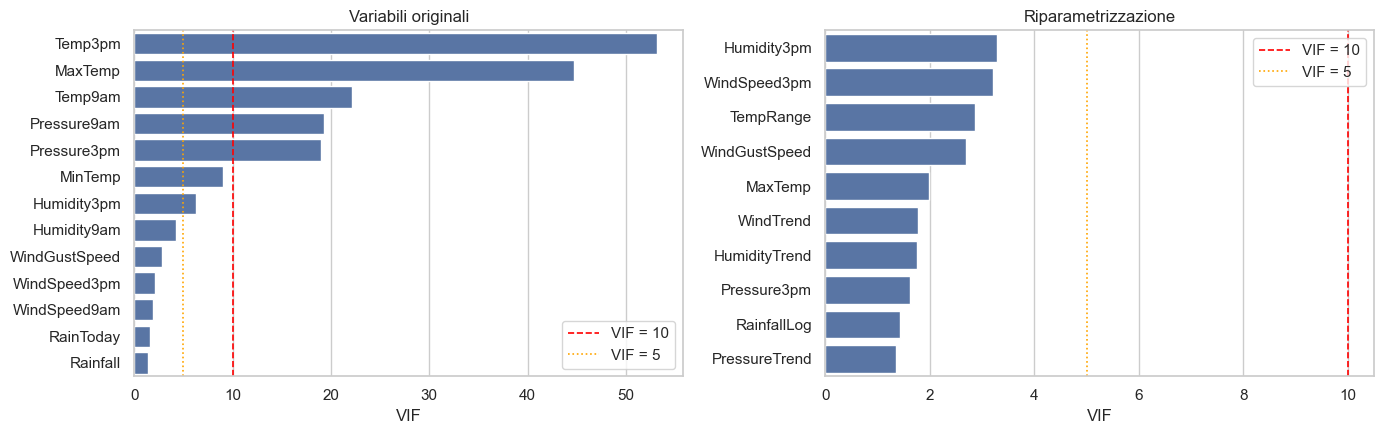

                  n. variabili  VIF massimo  VIF mediano  n. VIF > 10  Condition Index
originali                   13        53.13         6.28            5            21.22
riparametrizzate            10         3.28         1.89            0             4.30


In [158]:
d = df.copy()
d["TempRange"]     = d["MaxTemp"]      - d["MinTemp"]
d["PressureTrend"] = d["Pressure3pm"]  - d["Pressure9am"]
d["HumidityTrend"] = d["Humidity3pm"]  - d["Humidity9am"]
d["WindTrend"]     = d["WindSpeed3pm"] - d["WindSpeed9am"]
d["RainfallLog"]   = np.log1p(d["Rainfall"])

pred_eng = ["MaxTemp", "TempRange", "RainfallLog", "WindGustSpeed",
            "WindSpeed3pm", "WindTrend", "Humidity3pm", "HumidityTrend",
            "Pressure3pm", "PressureTrend"]

vif_eng = vif_table(d, pred_eng)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, (v, titolo) in zip(ax, [(vif_core, "Variabili originali"),
                               (vif_eng,  "Riparametrizzazione")]):
    sns.barplot(x=v.values, y=v.index, color="#4C72B0", ax=a)
    a.axvline(10, color="red", ls="--", lw=1.2, label="VIF = 10")
    a.axvline(5,  color="orange", ls=":", lw=1.2, label="VIF = 5")
    a.set_title(titolo); a.set_xlabel("VIF"); a.set_ylabel(""); a.legend()
plt.tight_layout(); plt.show()

riepilogo = pd.DataFrame({
    "n. variabili":    [len(pred_core), len(pred_eng)],
    "VIF massimo":     [vif_core.max(), vif_eng.max()],
    "VIF mediano":     [vif_core.median(), vif_eng.median()],
    "n. VIF > 10":     [(vif_core > 10).sum(), (vif_eng > 10).sum()],
    "Condition Index": [condition_index(df, pred_core), condition_index(d, pred_eng)],
}, index=["originali", "riparametrizzate"]).round(2)
print(riepilogo.to_string())

### Le feature derivate restano informative?

Abbassare il VIF non serve a nulla se nel farlo si distrugge il segnale. La verifica è
confrontare la correlazione col target prima e dopo: la tendenza barometrica e l'escursione
termica dovrebbero reggere il confronto, perché la fisica della pioggia dipende dalla
*variazione* delle grandezze e non solo dal loro livello.

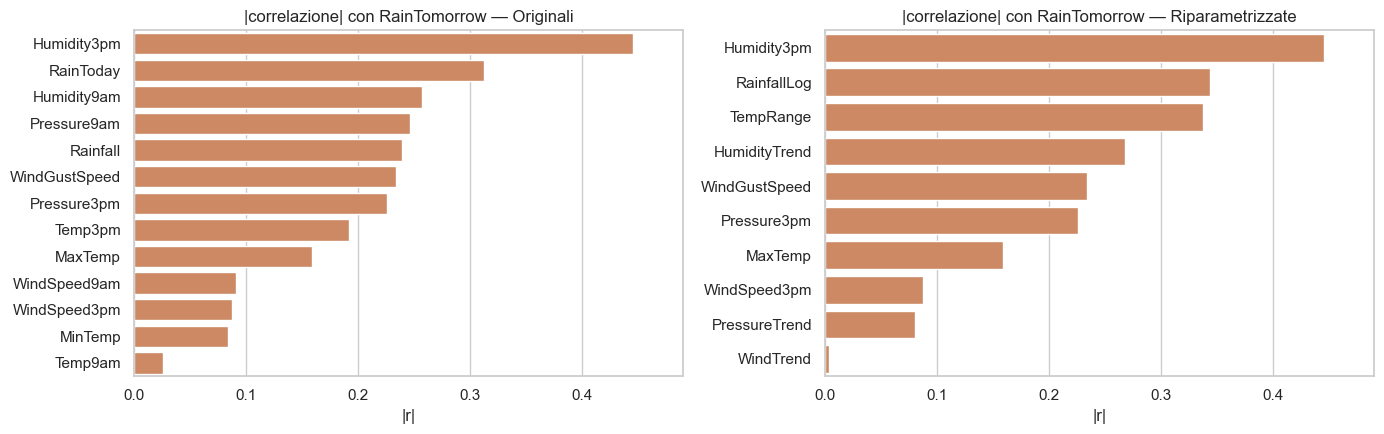

Correlazione assoluta col target — feature riparametrizzate:
Humidity3pm      0.446
RainfallLog      0.344
TempRange        0.338
HumidityTrend    0.268
WindGustSpeed    0.234
Pressure3pm      0.226
MaxTemp          0.159
WindSpeed3pm     0.088
PressureTrend    0.080
WindTrend        0.004


In [159]:
corr_prima = df[pred_core].corrwith(df[TARGET]).abs().sort_values(ascending=False)
corr_dopo  = d[pred_eng].corrwith(d[TARGET]).abs().sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
lim = max(corr_prima.max(), corr_dopo.max()) * 1.1
for a, (c, titolo) in zip(ax, [(corr_prima, "Originali"), (corr_dopo, "Riparametrizzate")]):
    sns.barplot(x=c.values, y=c.index, color="#DD8452", ax=a)
    a.set_title(f"|correlazione| con {TARGET} — {titolo}")
    a.set_xlabel("|r|"); a.set_ylabel(""); a.set_xlim(0, lim)
plt.tight_layout(); plt.show()

print("Correlazione assoluta col target — feature riparametrizzate:")
print(corr_dopo.round(3).to_string())

## 9. Ridondanza fra `Rainfall` e `RainToday`

* `Rainfall` — millimetri di pioggia nelle 24 ore che terminano alle 9:00 del giorno *t*;
* `RainToday` — vale `Yes` se e solo se `Rainfall > 1 mm`.

`RainToday` è quindi una funzione deterministica di `Rainfall`, non un'informazione aggiuntiva.
Nessuna delle due è leakage: si riferiscono entrambe al giorno *t*, mentre il target è il giorno
*t+1*.

In [160]:
mask_ok = df["Rainfall"].notna() & df["RainToday"].notna()
derivata = (df.loc[mask_ok, "Rainfall"] > 1.0).astype(int)
accordo = (derivata == df.loc[mask_ok, "RainToday"].astype(int)).mean()

print(f"RainToday coincide con (Rainfall > 1mm) nel {accordo:.0%} delle righe non mancanti")
print(f"\nMancanti Rainfall : {df['Rainfall'].isna().sum():,}")
print(f"Mancanti RainToday: {df['RainToday'].isna().sum():,}")
print(f"Mancanti insieme  : {(df['Rainfall'].isna() & df['RainToday'].isna()).sum():,}")
print(f"\nCorrelazione col target -> Rainfall: {target_corr['Rainfall']:.3f} | "
      f"RainToday: {target_corr['RainToday']:.3f}")

RainToday coincide con (Rainfall > 1mm) nel 100% delle righe non mancanti

Mancanti Rainfall : 1,406
Mancanti RainToday: 1,406
Mancanti insieme  : 1,406

Correlazione col target -> Rainfall: 0.239 | RainToday: 0.313


Le due colonne hanno esattamente gli stessi mancanti, quindi imputarle entrambe significa
applicare due volte la stessa imputazione.

**Indicazione per la modellazione:** tenere la sola `Rainfall`. La variabile continua contiene
tutto ciò che contiene la binaria (un albero ricostruisce da solo la soglia a 1 mm, un modello
lineare no ma guadagna la gradazione di intensità: 2 mm e 200 mm non sono la stessa cosa).
Vista l'asimmetria misurata nella sezione 6, conviene applicarle `log1p`.

## 10. Relazione tra le variabili meteo più informative e `RainTomorrow`

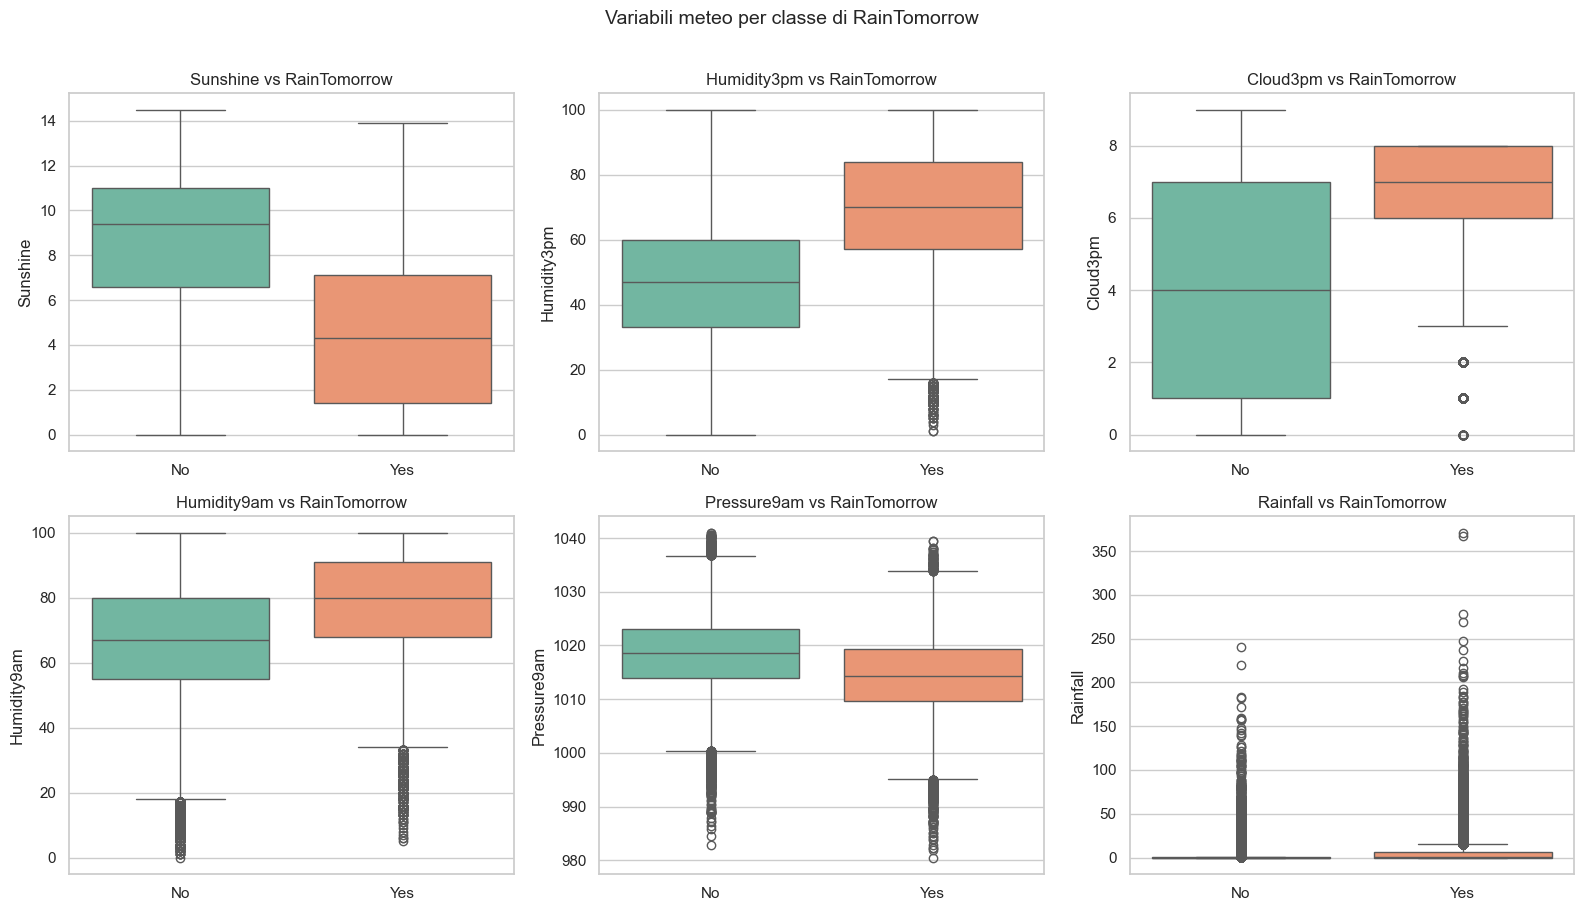

In [ ]:
#top_vars = ["Sunshine", "Humidity3pm", "Cloud3pm", "Humidity9am", "Pressure9am", "Rainfall"]
# le 6 feature più correlate col target, escluse le binarie
top_vars = [c for c in target_corr.index if c not in ["RainToday"]][:6]
print("Variabili selezionate (top 6 per |correlazione|):", top_vars)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.ravel(), top_vars):
    sns.boxplot(x="RainTomorrow", y=col, data=df, hue="RainTomorrow",
                palette="Set2", legend=False, ax=ax)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["No", "Yes"])
    ax.set_title(f"{col} vs RainTomorrow")
    ax.set_xlabel("")
plt.suptitle("Variabili meteo per classe di RainTomorrow", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

## 11. Persistenza della pioggia: `RainToday` vs `RainTomorrow`

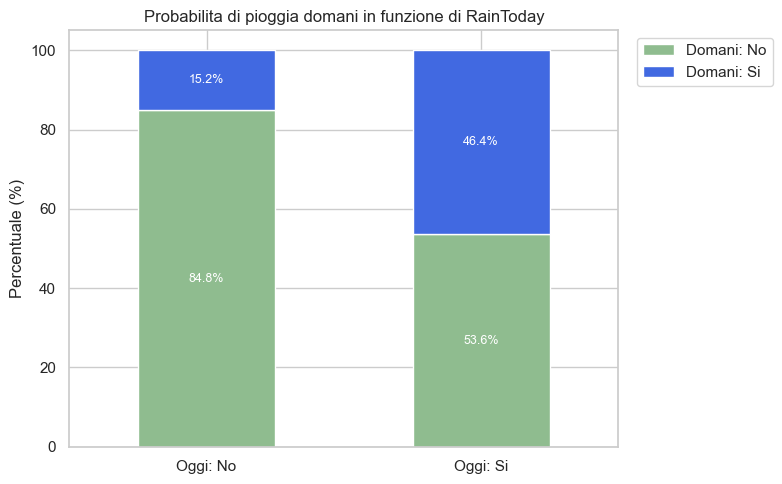

Baseline 'domani come oggi' -> accuratezza 76.232%
Baseline 'non piove mai'    -> accuratezza 77.582%


In [162]:
ct = pd.crosstab(df["RainToday"], df["RainTomorrow"], normalize="index") * 100
ct = ct.rename(index={0: "Oggi: No", 1: "Oggi: Si"},
               columns={0: "Domani: No", 1: "Domani: Si"})
ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5),
             color=["#8FBC8F", "#4169E1"])
plt.title("Probabilita di pioggia domani in funzione di RainToday")
plt.ylabel("Percentuale (%)"); plt.xlabel("")
plt.xticks(rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", label_type="center", color="white", fontsize=9)
plt.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Accuratezza della baseline di persistenza
m = df["RainToday"].notna()
acc = (df.loc[m, "RainToday"] == df.loc[m, "RainTomorrow"]).mean()
print(f"Baseline 'domani come oggi' -> accuratezza {acc:.3%}")
print(f"Baseline 'non piove mai'    -> accuratezza {1 - df['RainTomorrow'].mean():.3%}")

## 12. Direzione della raffica di vento e pioggia

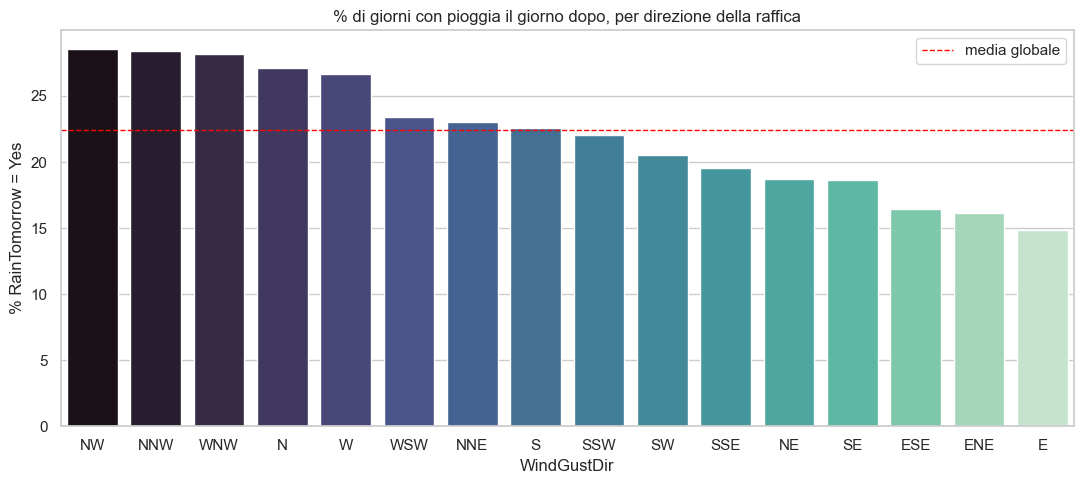

In [163]:
rain_by_dir = (df.groupby("WindGustDir")["RainTomorrow"].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(11, 5))
sns.barplot(x=rain_by_dir.index, y=rain_by_dir.values,
            hue=rain_by_dir.index, palette="mako", legend=False)
plt.axhline(df["RainTomorrow"].mean()*100, color="red", ls="--", lw=1, label="media globale")
plt.title("% di giorni con pioggia il giorno dopo, per direzione della raffica")
plt.ylabel("% RainTomorrow = Yes"); plt.xlabel("WindGustDir")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Stagionalità

Il mese è usato come feature categorica statica (stagionalità), non come indice temporale.
`Month` cattura il ciclo annuale ed è possibile utilizzarlo come
predittore, mentre `Date` non deve entrare fra le feature ma serve a definire lo split
cronologico.

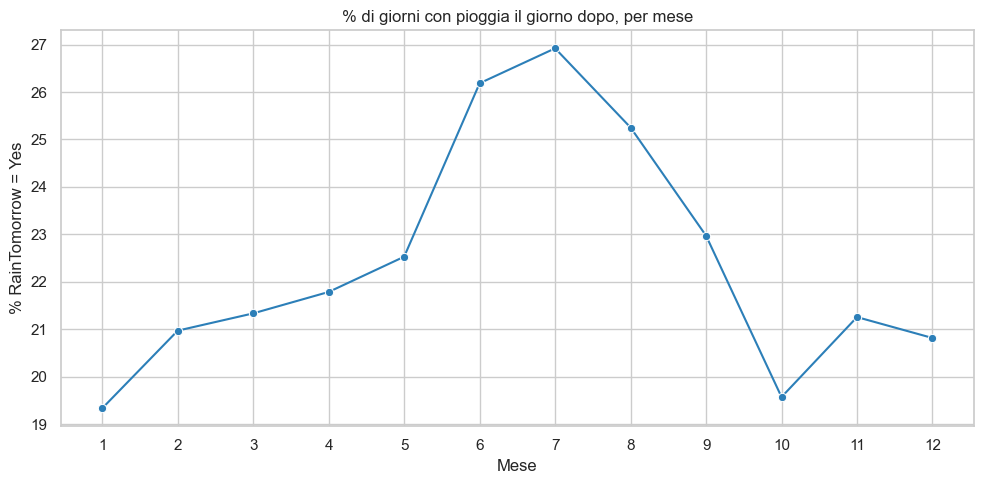

In [164]:
df["Month"] = df["Date"].dt.month
rain_by_month = df.groupby("Month")["RainTomorrow"].mean() * 100
plt.figure(figsize=(10, 5))
sns.lineplot(x=rain_by_month.index, y=rain_by_month.values, marker="o", color="#2C7FB8")
plt.title("% di giorni con pioggia il giorno dopo, per mese")
plt.xlabel("Mese"); plt.ylabel("% RainTomorrow = Yes")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 14. Differenze tra località

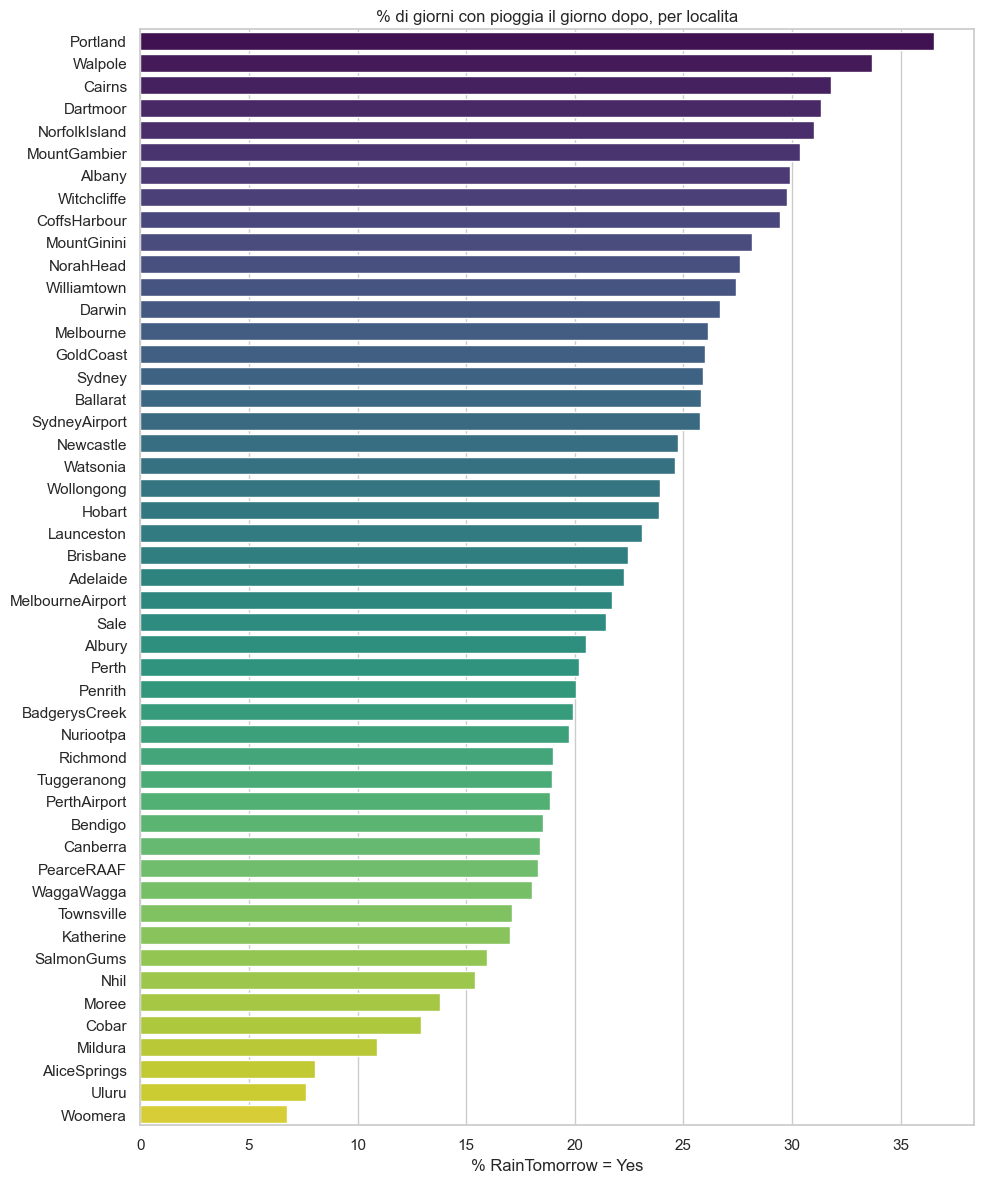

Range fra localita': da 6.8% a 36.5%
--> Location e' informativa e va inclusa fra le feature (one-hot).


In [165]:
rain_by_loc = (df.groupby("Location")["RainTomorrow"].mean() * 100).sort_values(ascending=False)
plt.figure(figsize=(10, 12))
sns.barplot(x=rain_by_loc.values, y=rain_by_loc.index,
            hue=rain_by_loc.index, palette="viridis", legend=False)
plt.title("% di giorni con pioggia il giorno dopo, per localita")
plt.xlabel("% RainTomorrow = Yes"); plt.ylabel("")
plt.tight_layout()
plt.show()

print(f"Range fra localita': da {rain_by_loc.min():.1f}% a {rain_by_loc.max():.1f}%")
print("--> Location e' informativa e va inclusa fra le feature (one-hot).")

## 15. Sintesi per la fase di modellazione

**Struttura dei dati.** Panel di 49 serie storiche giornaliere 2007-2017, chiave
(`Location`, `Date`). Il file non è ordinato per data. La pioggia è autocorrelata: giorni
adiacenti non sono indipendenti. Ne segue che lo split train/test deve essere **cronologico e
tagliato su una data**, e la cross-validation deve usare `TimeSeriesSplit`.

**Target.** `RainTomorrow` sbilanciato circa 78/22. L'accuracy non è una metrica adeguata: la
baseline "non piove mai" la ottiene quasi gratis. Si useranno F1, ROC-AUC e PR-AUC, e il modello
va confrontato con la baseline di persistenza.

**Valori mancanti.** Strutturali, per intere stazioni. `Sunshine`, `Evaporation`, `Cloud9am` e
`Cloud3pm` superano il 38%. `Sunshine` e `Cloud3pm` sono però fra le più correlate col target,
quindi scartarle ha un costo: l'alternativa è imputarle aggiungendo un indicatore di mancanza.

**Multicollinearità.** VIF elevato sulle quattro temperature e sulle due pressioni, Condition
Index oltre la soglia. `RainToday` è una funzione deterministica di `Rainfall`. Documentata qui;
per i modelli ad albero non è un problema di accuratezza, ma va tenuta presente se si
interpretano i coefficienti dei modelli lineari.

**Leakage.** `RISK_MM` verificata assente. Il rischio residuo è temporale ed è gestito nel
notebook di classificazione.